In [253]:
import numpy as np
import pandas as pd

In [255]:
cources = pd.read_csv('courses.csv')
student = pd.read_csv('students.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')

matches = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')

In [257]:
cources.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [259]:
student.head()

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6


In [261]:
nov.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [263]:
dec.head()

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9


In [265]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [267]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [269]:
##  pd.concat
## ignore_index
## df.append   -->deprecated
## multiindex --> fetch using iloc
## concat dataframes horizontally

In [271]:
## concat vertically (number of columns must be equal)
pd.concat([nov,dec])

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [273]:
## index are not repeating 
regs = pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [275]:
multi = pd.concat([nov,dec],keys=['nov','dec'])

In [277]:
multi.loc['nov']
multi.loc['dec']

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [279]:
## fetching a particular row
multi.loc[('nov',4)]

student_id    16
course_id      9
Name: (nov, 4), dtype: int64

In [281]:
multi.loc[('dec',6)]

student_id    7
course_id     2
Name: (dec, 6), dtype: int64

In [283]:
## concat horizontally (no matter number of columns are equal or not)
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


### Joining

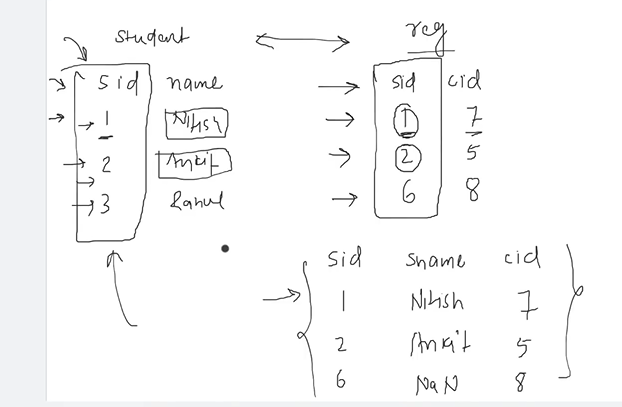

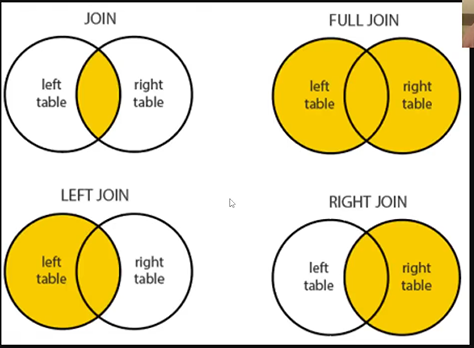

In [288]:
## inner join  (only common part will come )
student.head()

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6


In [290]:
regs.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [292]:
student.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [294]:
## left join
cources.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [296]:
## right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankit','Rahul'],
    'partner':[28,26,17]
})
student = pd.concat([student,temp_df],ignore_index=True)

In [298]:
student.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [300]:
student.merge(regs,how='left',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,1,Kailash Harjo,23,6.0
2,1,Kailash Harjo,23,10.0
3,1,Kailash Harjo,23,9.0
4,2,Esha Butala,1,5.0
5,3,Parveen Bhalla,3,3.0
6,3,Parveen Bhalla,3,5.0
7,4,Marlo Dugal,14,NaN
8,5,Kusum Bahri,6,NaN
9,6,Lakshmi Contractor,10,NaN


In [302]:
## full outer join
student.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,28.0,NaN
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [304]:
## find the total revenue generated by the company
cources.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [306]:
regs.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [308]:
regs.merge(cources,how='inner',on='course_id')['price'].sum()

154247

In [310]:
## find month by month revenue
nov_revnue = nov.merge(cources,how='inner',on='course_id')['price'].sum()
nov_revnue

89175

In [312]:
dec_revnue = dec.merge(cources,how='inner',on='course_id')['price'].sum()
dec_revnue

65072

In [314]:
temp_df = pd.concat([nov,dec],keys=['nov','dec']).reset_index()
temp_df.merge(cources,on='course_id').groupby('level_0')['price'].sum()

level_0
dec    65072
nov    89175
Name: price, dtype: int64

In [316]:
## print the registration table
##  cols -> name -> course -> price
student.head()

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6


In [318]:
regs.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [320]:
cources.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [322]:
temp_df = student.merge(regs,on='student_id')
temp_df.merge(cources,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Kailash Harjo,python,2499
1,Kailash Harjo,power bi,1899
2,Kailash Harjo,pyspark,2499
3,Kailash Harjo,plotly,699
4,Esha Butala,tableau,2499
5,Parveen Bhalla,data analysis,4999
6,Parveen Bhalla,tableau,2499
7,Tarun Thaker,pandas,1099
8,Tarun Thaker,pyspark,2499
9,Tarun Thaker,ms sxcel,1599


<Axes: xlabel='course_name'>

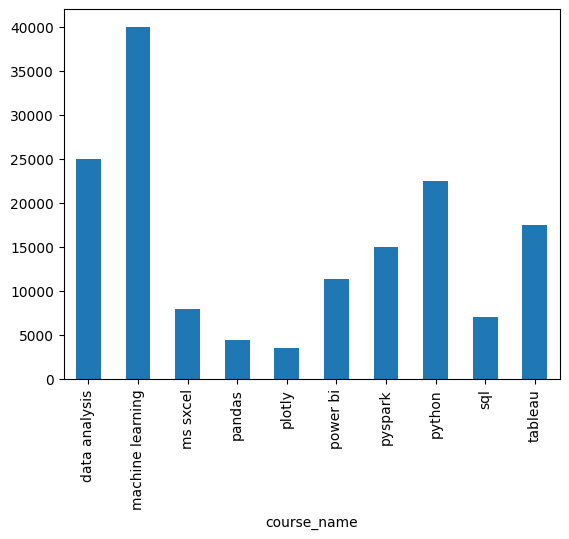

In [324]:
## plot bar chart for revenue / course
regs.merge(cources,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [326]:
### find students who enrolled in both the month

In [328]:
common_student_id = np.intersect1d(nov['student_id'], dec['student_id'])
student[student['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [330]:
## find course that got no enrollment
cources.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [332]:
regs.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [334]:
cource_id_list = np.setdiff1d(cources['course_id'],regs['course_id'])
cources[cources['course_id'].isin(cource_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [341]:
## find student who did not enroll in any course
student_id_list = np.setdiff1d(student['student_id'],regs['student_id'])
student[student['student_id'].isin(student_id_list)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
25,26,Nitish,28
26,27,Ankit,26
27,28,Rahul,17


In [345]:
## print students -> partner name for all enrolled students
## self join
student.merge(student,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [373]:
## find top three students who did most number of enrollments

In [377]:
regs.merge(student,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False)

student_id  name              
23          Chhavi Lachman        6
7           Tarun Thaker          5
1           Kailash Harjo         4
12          Radha Dutt            4
14          Pranab Natarajan      4
16          Elias Dodiya          4
11          David Mukhopadhyay    3
18          Fardeen Mahabir       3
22          Yash Sethi            3
15          Preet Sha             2
17          Yasmin Palan          2
19          Qabeel Raman          2
3           Parveen Bhalla        2
25          Shashank D’Alia       2
13          Munni Varghese        1
2           Esha Butala           1
21          Seema Kota            1
24          Radhika Suri          1
Name: name, dtype: int64

In [395]:
## find top three students who spent most amount of money on cources
regs.merge(student,on='student_id').merge(cources,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [397]:
## alternate syntax for merge 
## pd.merge(df1,df2,how,on)

pd.merge(student,regs,on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [401]:
### IPL Problems
# find top 3 stadium with highest sixes/match ratio
# find orange cap holder of all the seasons

In [403]:
matches.head(2)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


In [405]:
delivery.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [409]:
temp_df = delivery.merge(matches,left_on='match_id',right_on='id')

In [433]:
six_df = temp_df[temp_df['batsman_runs']==6]

In [453]:
num_six= six_df.groupby('venue')['venue'].count()
num_six

venue
Barabati Stadium                                         68
Brabourne Stadium                                       114
Buffalo Park                                             27
De Beers Diamond Oval                                    34
Dr DY Patil Sports Academy                              173
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     129
Dubai International Cricket Stadium                      58
Eden Gardens                                            594
Feroz Shah Kotla                                        636
Green Park                                               36
Himachal Pradesh Cricket Association Stadium            108
Holkar Cricket Stadium                                   88
JSCA International Stadium Complex                       76
Kingsmead                                               130
M Chinnaswamy Stadium                                   873
MA Chidambaram Stadium, Chepauk                         507
Maharashtra Cricket Association St

In [455]:
matches_num = matches['venue'].value_counts().sort_index()
matches_num

venue
Barabati Stadium                                         7
Brabourne Stadium                                       11
Buffalo Park                                             3
De Beers Diamond Oval                                    3
Dr DY Patil Sports Academy                              17
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     11
Dubai International Cricket Stadium                      7
Eden Gardens                                            61
Feroz Shah Kotla                                        60
Green Park                                               4
Himachal Pradesh Cricket Association Stadium             9
Holkar Cricket Stadium                                   5
JSCA International Stadium Complex                       7
Kingsmead                                               15
M Chinnaswamy Stadium                                   66
MA Chidambaram Stadium, Chepauk                         48
Maharashtra Cricket Association Stadium           

In [463]:
(num_six/matches_num).sort_values(ascending=False).head(3)

venue
Holkar Cricket Stadium     17.600000
M Chinnaswamy Stadium      13.227273
Sharjah Cricket Stadium    12.666667
dtype: float64

In [477]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum()

season  batsman          
2008    A Chopra              42
        A Kumble              13
        A Mishra              37
        A Mukund               0
        A Nehra                3
                            ... 
2017    Washington Sundar      9
        YK Pathan            143
        YS Chahal             13
        Yuvraj Singh         252
        Z Khan                 4
Name: batsman_runs, Length: 1531, dtype: int64

In [493]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
